![](img/gun.jpeg){width=500}

Shootings in Philadelphia are often discussed in terms of annual totals - how many incidents occured this year compared to others. But those figures alone don't tell us much about when gun violence actually happens in the city. Are shootings concentrated at certain times of the day? Are there more incidents on specific days of the week? And how does gun violence change with the seasons? In this post, I use open Philadelphia shooting data, along with historical weather data, to explore patterns in shootings incidents across time and weather conditions to better understand when violence is most likely to occur. 

Shootings are most often thought to occur at night. But is that really the case?

Set up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [2]:
shoot = pd.read_csv('data/shootings.csv') 

Extracting hour from time variable and creating bar plot

In [3]:
shoot['time'] = pd.to_datetime(shoot['time'])

shoot['hour'] = shoot['time'].dt.hour

hour_counts = shoot['hour'].value_counts().sort_index()

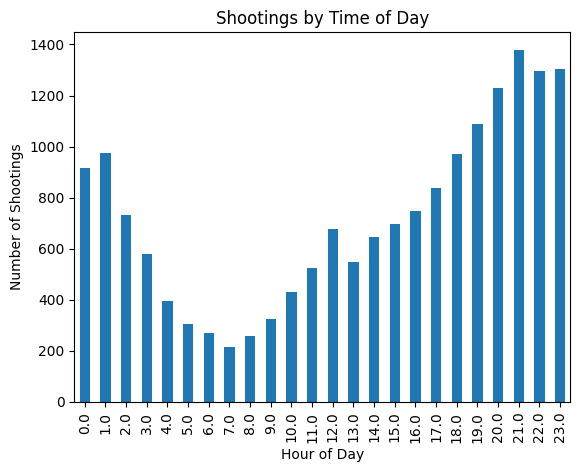

In [4]:
hour_counts.plot(kind = 'bar')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Shootings")
plt.title("Shootings by Time of Day")
plt.show()

This graph shows the total count of shooting incidents by the hour of the day. As expected, there is a disproportionate amount of shootings in the evening and early morning, with the total per hour steadily rising from 1:00 PM and peaking at 9:00 PM. However, hourly counts remain high until about 1:00 AM before rapidly falling through the rest of the morning.

This makes sense since more people may be out in social settings (and away from more structured environments like work), alcohol use is higher, and there's less public visibility. But how do these trends carry over the course of the week?

Creating bar chart

In [5]:
shoot['date_'] = pd.to_datetime(shoot['date_'])

shoot['day_of_week'] = shoot['date_'].dt.day_name()

day_counts = shoot['day_of_week'].value_counts()

In [6]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(order)

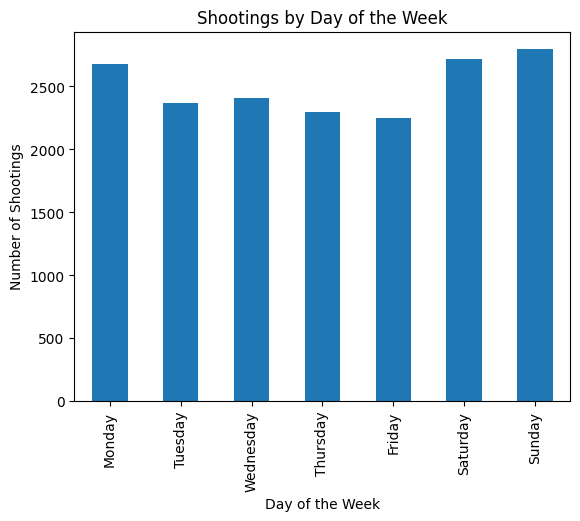

In [7]:
day_counts.plot(kind = 'bar')
plt.xlabel("Day of the Week")
plt.ylabel("Number of Shootings")
plt.title("Shootings by Day of the Week")
plt.show()

The total amount of shootings each day of the week does not vary as much as the hours, but there is a higher count of incidents on the weekend. This is consistent with what we saw looking at the time of day, suggesting that shootings are more closely tied with periods of increased social activity - particularly nights and weekends - rather than being evenly distributed throughout the week.

Do similar patterns emerge over longer periods of time, like the months of the year?

Creating a line plot

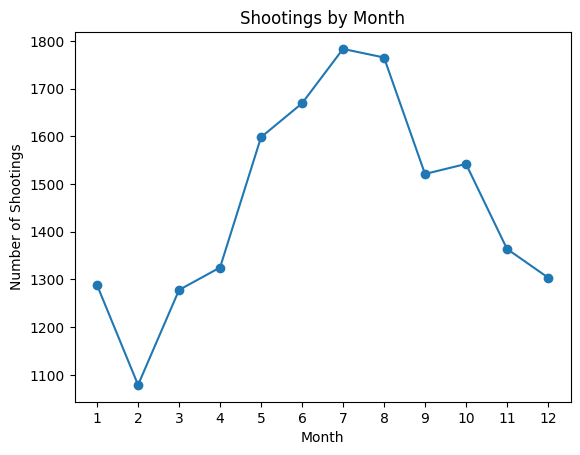

In [8]:
shoot['month'] = shoot['date_'].dt.month

month_counts = shoot['month'].value_counts().sort_index()

plt.plot(month_counts.index, month_counts.values, marker = 'o')

plt.xlabel("Month")
plt.ylabel("Number of Shootings")
plt.title("Shootings by Month")
plt.xticks(range(1, 13))
plt.show()

It seems so. The majority of shootings in Philadelphia seem to be concentrated in the spring and summer months, with the highest amount of shooting ocurring in July. This continues to support the working idea that gun violence incidents are associated with more social periods since people tend to engage in more recreational activities in warmer weather. However, it remains unclear whether this pattern is driven by the time of year itself or by the weather conditions that come with it.

Merging the Philadelphia shooting data with historical weather data, I looked to see how temperature relates to shootings. 

Merging data

In [9]:
weather = pd.read_csv('data/weather.csv')

In [10]:
weather['date'] = pd.to_datetime(weather['date'])

shoot_weather = shoot.merge(
    weather,
    left_on = 'date_',
    right_on = 'date',
    how = 'left'
)

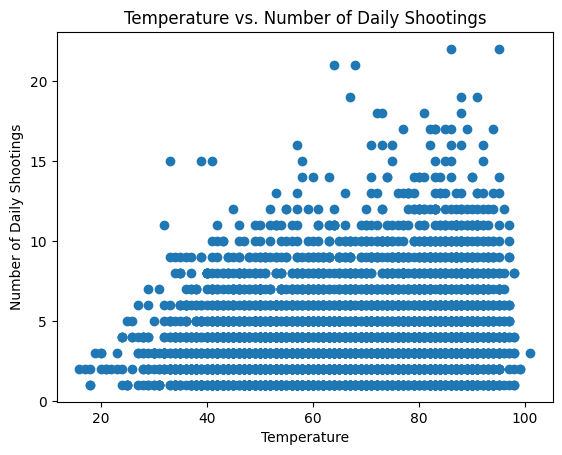

In [11]:
daily_shootings = shoot_weather.groupby('date_').size().reset_index(name = 'shootings')
#ChatGPT suggested this data restructure

daily = daily_shootings.merge(
    weather,
    left_on = 'date_',
    right_on = 'date',
    how = 'left'
)

plt.scatter(daily['high'], daily['shootings'])
plt.xlabel("Temperature")
plt.ylabel("Number of Daily Shootings")
plt.title("Temperature vs. Number of Daily Shootings")

plt.show()

This graph shows the relationship between temperature and the amount of shootings on a given day. There is a clear upward trend, with higher temperatures generally associated with more shootings. This suggests that heat may play a role in driving gun violence. But temperature alone doesn't fully explain these patterns. By analyzing Philadelphia rain fall patterns, we can better isolate for the effects of outside activity, irrespective of season, in Philadelphia shootings.

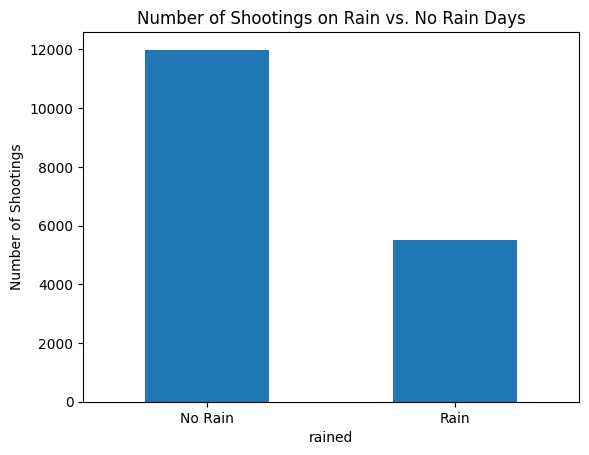

In [14]:
shoot_weather['rained'] = shoot_weather['rain'] > 0

rain_total = shoot_weather.groupby('rained').size()
rain_total.plot(kind = 'bar')
plt.xticks([0, 1], ['No Rain', 'Rain'], rotation = 0)
plt.ylabel("Number of Shootings")
plt.title("Number of Shootings on Rain vs. No Rain Days")
plt.show()

Looking at the distribution, shootings are significantly more common on days it does not rain than on rainy days, which is consistent with the idea that reduced outdoor activity may limit opportunities for violent encounters. However, it's worth noting that, because this comparison reflects total counts counts rather than rates, some of the differences may also be driven by the greater number of rainy days overall.

Although we tend to think about shooting figures in terms of annual counts, it's important to acknowledge that shootings in Philadelphia are not randomly distributed, but rather follow distinct patterns across time and weather conditions. Shootings tend to be concentrated around weekend late nights and they rise during the spring and summer months. Additionally, there is a positive relationship between temperature and gun violence, which along with the rainfall data, further suggests that shootings are associated with outdoor and social activity. Even though this analysis was highly limited, understanding these patterns are important for not only making safer decisions but also for designing city policy and systems to reduce gun violence.